# Aula 01

In [ ]:
import pandas as pd

uri = "https://gist.githubusercontent.com/jessicadesousa/56ac5efd1b9f2a06ef503485e904a203/raw/d829a7204ad55506644f4a7058090c84424217e7/machine-learning-carros-simulacion.csv"
datos = pd.read_csv(uri)
datos.head()

,precio,vendido,edad_del_modelo,km_por_ano
0,30941.02,1,18,35085.22134
1,40557.96,1,20,12622.05362
2,89627.50,0,12,11440.79806
3,95276.14,0,3,43167.32682
4,117384.68,1,4,12770.11290


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x = datos[["precio", "edad_del_modelo", "km_por_ano"]]
y = datos["vendido"]

SEED = 158020
np.random.seed(SEED)

train_x, test_x, train_y, test_y = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    stratify = y)

print("Entrenaremos con %d elementos y evaluaremos con %d elementos" %(len(train_x), len(test_y)))

Entrenaremos con 7500 elementos y evaluaremos con 2500 elementos



##**DummyClassifier**
es una clase proporcionada por la biblioteca scikit-learn (sklearn) en Python que se utiliza como un clasificador "tonto" o "dummy". Su propósito principal es proporcionar una referencia básica para comparar con otros clasificadores más complejos.

Este clasificador es útil en varias situaciones, como:

1. **Baseline Testing:** Antes de probar clasificadores más avanzados, es útil tener una línea base para comparar. El DummyClassifier proporciona esa referencia básica.

2. **Debugging:** Al depurar un flujo de trabajo de aprendizaje automático, a veces es útil tener un clasificador muy simple para detectar problemas o errores en el código más complejo.

3. **Baseline en Imbalance de Clases**: Cuando se enfrenta a conjuntos de datos con clases desequilibradas, donde una clase es mucho más frecuente que otras, el DummyClassifier puede ser útil como una referencia para determinar si los modelos más sofisticados están aprendiendo adecuadamente de las clases minoritarias.

El DummyClassifier proporciona varias estrategias básicas de clasificación, como clasificar aleatoriamente o siempre predecir la clase más frecuente en el conjunto de entrenamiento. Esto permite evaluar rápidamente cómo se desempeñan los clasificadores más avanzados en comparación con estas estrategias básicas.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_stratified = DummyClassifier(strategy="stratified")
dummy_stratified.fit(train_x, train_y)
accuracy = dummy_stratified.score(test_x, test_y) * 100

print("La exactitud(accuracy) del dummy stratified fue %.2f%%" % accuracy)

La exactitud(accuracy) del dummy stratified fue 50.96%


In [ ]:
from sklearn.tree import DecisionTreeClassifier

SEED = 158020
np.random.seed(SEED)

modelo = DecisionTreeClassifier(max_depth=2)
modelo.fit(train_x, train_y)

predicciones = modelo.predict(test_x)

accuracy = accuracy_score(test_y, predicciones) * 100
print("La exactitud(accuracy) fue %.2f%%" % accuracy)

La exactitud(accuracy) fue 71.92%


In [ ]:
'''al cambiar la semilla de reprosidad se obtienen diferentes resultados
esto es devido a que cambian los valores en los conjuntos o variables:
train_x, test_x, train_y, test_y '''
SEED = 5
np.random.seed(SEED)

train_x, test_x, train_y, test_y = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    stratify = y)

modelo = DecisionTreeClassifier(max_depth=2)
modelo.fit(train_x, train_y)

predicciones = modelo.predict(test_x)

accuracy = accuracy_score(test_y, predicciones) * 100
print("La exactitud(accuracy) fue %.2f%%" % accuracy)

La exactitud(accuracy) fue 76.84%


## Corss validate

**cross_validate**

es una función de la librería scikit-learn que se utiliza para realizar validación cruzada en modelos de aprendizaje automático. Esta función permite realizar la validación cruzada de manera sencilla y obtener métricas de evaluación del modelo, como precisión, recall, F1-score, entre otros.

Algunos de los parámetros más comunes de la función cross_validate son:

+ estimator: El modelo de aprendizaje automático que se va a evaluar.
+ X: Las características de entrada.
+ y: Las etiquetas de salida.
+ scoring: La métrica de evaluación que se desea utilizar, como "accuracy" para precisión, "precision" para precisión, "recall" para recall, etc.
+ cv: El esquema de validación cruzada a utilizar, por ejemplo, un entero para especificar el número de pliegues en una validación cruzada k-fold.

cross_validate devuelve un diccionario con información sobre las métricas de evaluación para cada pliegue de la validación cruzada, lo que permite analizar el rendimiento del modelo de manera más detallada. Esta función es útil para seleccionar modelos, ajustar hiperparámetros y evaluar la capacidad de generalización de un modelo.

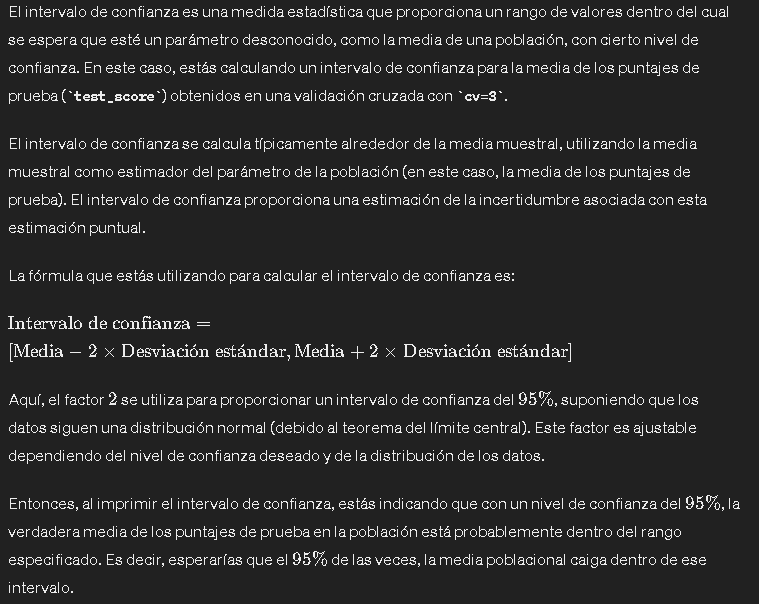

In [ ]:
from sklearn.model_selection import cross_validate

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x, y, cv=3)

media = resultados['test_score'].mean()
desviacion_standar = resultados['test_score'].std()

print('nuestro intervalo de confianza para cv=3 es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

nuestro intervalo de confianza para cv=3 es [74.99, 76.57]
La exactitud media fue 75.78% (+/- 0.40%)


**Camviando semilla de reprosidad**

In [ ]:
SEED = 234
np.random.seed(SEED)

modelo = DecisionTreeClassifier(max_depth=2)
resultados = cross_validate(modelo, x, y, cv=3)
media = resultados['test_score'].mean()
desviacion_standar = resultados['test_score'].std()

print('nuestro intervalo de confianza para cv=3 es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

nuestro intervalo de confianza para cv=3 es [74.99, 76.57]
La exactitud media fue 75.78% (+/- 0.40%)


**Cambiando el parametro cv**

However, if the learning curve is steep for the training size in question, then 5- or 10- fold cross validation can overestimate the generalization error.

As a general rule, most authors, and empirical evidence, suggest that 5- or 10- fold cross validation should be preferred to LOO.

INFO: https://scikit-learn.org/stable/modules/cross_validation.html

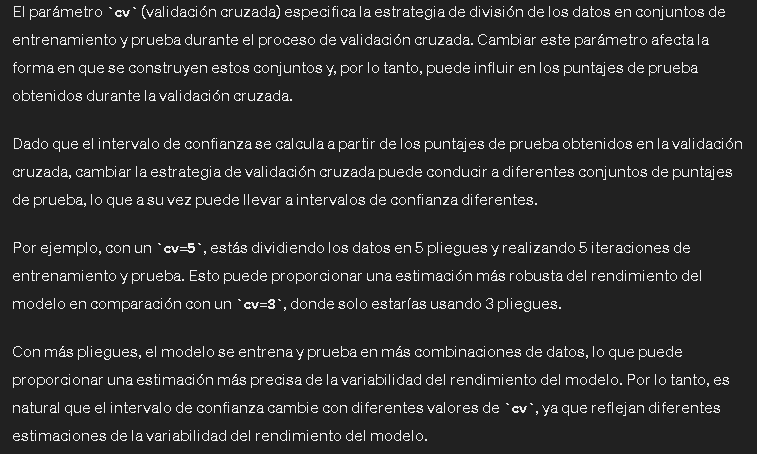

In [ ]:
SEED = 234
np.random.seed(SEED)

modelo = DecisionTreeClassifier(max_depth=2)
resultados = cross_validate(modelo, x, y, cv=5)
media = resultados['test_score'].mean()
desviacion_standar = resultados['test_score'].std()

print('nuestro intervalo de confianza para cv=3 es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

nuestro intervalo de confianza para cv=3 es [75.21, 76.35]
La exactitud media fue 75.78% (+/- 0.29%)


In [ ]:
SEED = 234
np.random.seed(SEED)

modelo = DecisionTreeClassifier(max_depth=2)
resultados = cross_validate(modelo, x, y, cv=10)
media = resultados['test_score'].mean()
desviacion_standar = resultados['test_score'].std()

print('nuestro intervalo de confianza para cv=3 es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

nuestro intervalo de confianza para cv=3 es [74.24, 77.32]
La exactitud media fue 75.78% (+/- 0.77%)


# Aula 02

## K-fold con aletoriedad

KFold es una clase en el módulo model_selection de la biblioteca scikit-learn (sklearn) que se utiliza para dividir los datos en varios subconjuntos (folds) para la validación cruzada. La validación cruzada es una técnica utilizada para evaluar el rendimiento de un modelo de aprendizaje automático de manera más robusta al dividir los datos en múltiples subconjuntos y entrenar y evaluar el modelo en diferentes combinaciones de estos subconjuntos.

¿Qué es KFold?
KFold divide los datos en k subconjuntos de tamaño aproximadamente igual. El proceso se repite k veces, cada vez utilizando un subconjunto diferente como conjunto de prueba y los k-1 subconjuntos restantes como conjunto de entrenamiento. Esto permite que cada muestra en el conjunto de datos se utilice exactamente una vez para la validación y k-1 veces para el entrenamiento.

¿Para qué sirve KFold?
El objetivo principal de KFold es proporcionar una estimación más fiable del rendimiento del modelo. Al evaluar el modelo en diferentes subconjuntos de los datos, se puede obtener una estimación más precisa de cómo se comportará el modelo en datos no vistos.

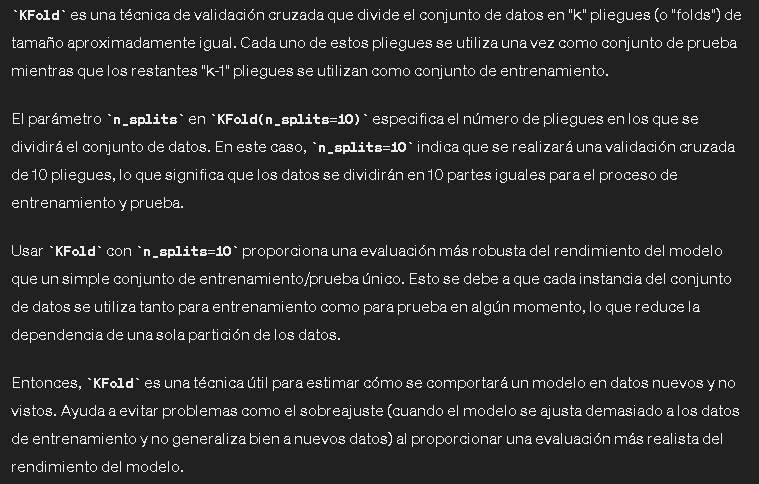

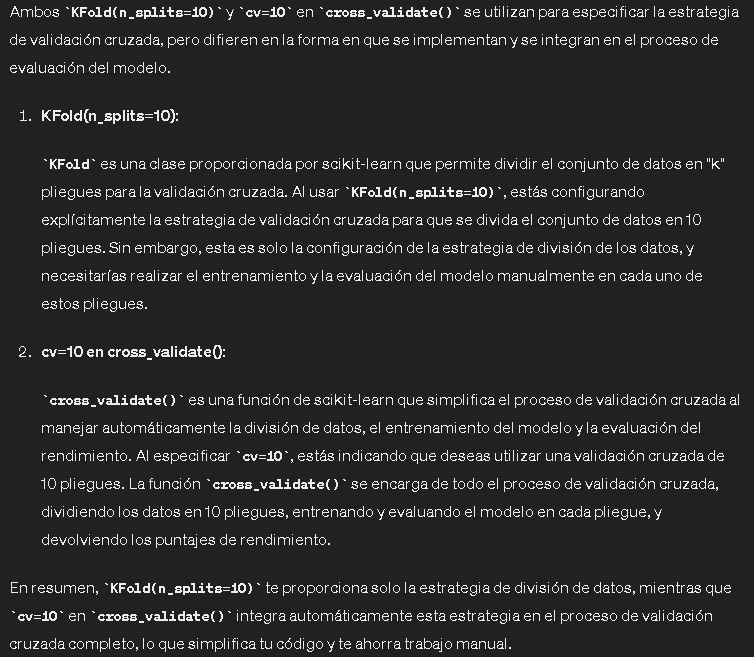



---



---



In [ ]:
from sklearn.model_selection import KFold

SEED = 234
np.random.seed(SEED)

cv = KFold(n_splits=10)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x, y, cv=cv)
media = resultados['test_score'].mean()
desviacion_standar = resultados['test_score'].std()

print('nuestro intervalo de confianza para cv=3 es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

nuestro intervalo de confianza para cv=3 es [74.37, 77.19]
La exactitud media fue 75.78% (+/- 0.70%)


In [ ]:
def imprime_resultadaos(resultados):
    media = resultados['test_score'].mean()
    desviacion_standar = resultados['test_score'].std()

    print('Nuestra media es %.2f' %(media*100))
    print('nuestro intervalo de confianza es [%.2f, %.2f]' %((media - 2 * desviacion_standar)*100, (media + 2 * desviacion_standar)*100))
    print("La exactitud media fue %.2f%% (+/- %.2f%%)" % ((media * 100), (desviacion_standar * 100)))

In [ ]:
SEED = 234
np.random.seed(SEED)

cv = KFold(n_splits=10)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x, y, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [74.37, 77.19]
La exactitud media fue 75.78% (+/- 0.70%)


In [ ]:
SEED = 234
np.random.seed(SEED)

cv = KFold(n_splits=10, shuffle=True)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x, y, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [71.82, 79.74]
La exactitud media fue 75.78% (+/- 1.98%)


# Aula 03

## Estratificación con validación cruzada
modelo de seleccion
https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection

### Simular datos ordenados - mala suerte

In [ ]:
datos_ordenados = datos.sort_values(by='vendido')

x_ordenado = datos_ordenados[["precio", "edad_del_modelo", "km_por_ano"]]
y_ordenado = datos_ordenados["vendido"]

datos_ordenados.head()

,precio,vendido,edad_del_modelo,km_por_ano
4999,74023.29,0,12,24812.80412
5322,84843.49,0,13,23095.63834
5319,83100.27,0,19,36240.72746
5316,87932.13,0,16,32249.56426
5315,77937.01,0,15,28414.50704


In [ ]:
SEED = 234
np.random.seed(SEED)

cv = KFold(n_splits=10)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x_ordenado, y_ordenado, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 57.84
nuestro intervalo de confianza es [34.29, 81.39]
La exactitud media fue 57.84% (+/- 11.77%)


In [ ]:
SEED = 234
np.random.seed(SEED)

cv = KFold(n_splits=10, shuffle=True)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x_ordenado, y_ordenado, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [72.73, 78.83]
La exactitud media fue 75.78% (+/- 1.53%)


###**StratifiedKFold**
es una clase en el módulo model_selection de la biblioteca scikit-learn que se utiliza para realizar validación cruzada estratificada. La validación cruzada estratificada es similar a la validación cruzada estándar, pero asegura que la proporción de las clases en cada fold (subconjunto) sea aproximadamente la misma que la proporción de clases en el conjunto de datos completo. Esto es especialmente útil cuando se trabaja con conjuntos de datos desbalanceados, donde algunas clases pueden ser mucho más frecuentes que otras.

**¿Qué es StratifiedKFold?**

StratifiedKFold divide los datos en k folds de manera que cada fold tiene aproximadamente la misma proporción de clases que el conjunto de datos original. Esto garantiza que cada fold sea representativo del conjunto de datos completo, lo cual puede resultar en una evaluación más precisa y confiable del rendimiento del modelo.

**¿Para qué sirve StratifiedKFold?**
StratifiedKFold se utiliza principalmente para:

1. **Asegurar la representación adecuada de todas las clases**: Mantiene la proporción de clases en cada fold, lo que es crucial cuando se trabaja con datos desbalanceados.
2. **Mejorar la evaluación del modelo:** Proporciona una estimación más precisa del rendimiento del modelo al garantizar que todas las clases estén representadas de manera equitativa en los datos de entrenamiento y prueba.
3. **Mitigar el riesgo de overfitting:** Al evaluar el modelo en diferentes particiones estratificadas del conjunto de datos, se obtiene una visión más robusta de cómo se comportará el modelo en datos no vistos.

In [ ]:
from sklearn.model_selection import StratifiedKFold

SEED = 234
np.random.seed(SEED)

cv = StratifiedKFold(n_splits=10)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x_ordenado, y_ordenado, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [73.83, 77.73]
La exactitud media fue 75.78% (+/- 0.97%)


In [ ]:
SEED = 234
np.random.seed(SEED)

cv = StratifiedKFold(n_splits=10, shuffle=True)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x_ordenado, y_ordenado, cv=cv)
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [73.33, 78.23]
La exactitud media fue 75.78% (+/- 1.22%)


## Documentación y buenas prácticas

modelos de seleccion
https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection

# Aula 04

##  Creando datos aleatórios

In [ ]:
datos['edad_del_modelo'].head()

0    18
1    20
2    12
3     3
4     4
Name: edad_del_modelo, dtype: int64

In [ ]:
# creando una colimna simulada de modelo de carro (es decir datos nuevos de modelo)
import numpy as np
SEED = 1234

np.random.seed(SEED)

modelo =  np.random.randint(low=-2, high=3, size=len(datos))
datos['modelo'] = datos['edad_del_modelo'] + modelo
datos['modelo'] = datos['modelo'] + abs(min(datos.modelo)) + 1
datos.head()

,precio,vendido,edad_del_modelo,km_por_ano,modelo
0,30941.02,1,18,35085.22134,21
1,40557.96,1,20,12622.05362,24
2,89627.50,0,12,11440.79806,16
3,95276.14,0,3,43167.32682,3
4,117384.68,1,4,12770.11290,5


In [ ]:
datos.modelo.unique()

array([21, 24, 16,  3,  5, 12, 17, 22, 19,  6, 11, 13, 20,  8, 18,  7, 10,
       14, 23, 15,  9,  4,  2,  1])

## Validación cruzada usando grupos

group kafol https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html


###**GroupKFold**
es una clase en el módulo model_selection de la biblioteca scikit-learn que se utiliza para realizar validación cruzada teniendo en cuenta grupos específicos dentro de los datos. A diferencia de KFold y StratifiedKFold, GroupKFold garantiza que las observaciones de un mismo grupo no se dividan entre el conjunto de entrenamiento y el conjunto de prueba. Esto es útil cuando hay dependencias o correlaciones dentro de los grupos que podrían sesgar la evaluación del modelo si se ignoraran.

**¿Qué es GroupKFold?**

GroupKFold divide los datos en k folds de manera que las observaciones pertenecientes al mismo grupo se mantengan juntas en el mismo fold. Esto significa que las observaciones de un grupo específico estarán completamente en el conjunto de entrenamiento o completamente en el conjunto de prueba en cada iteración de la validación cruzada.

**¿Para qué sirve GroupKFold?**

GroupKFold se utiliza principalmente para:

1. **Manejar dependencias dentro de grupos**: Asegura que las observaciones de un mismo grupo no se mezclen entre los conjuntos de entrenamiento y prueba, lo que es crucial cuando las observaciones dentro de un grupo no son independientes entre sí.
2. **Evaluar modelos de manera más realista**: Proporciona una evaluación más realista del rendimiento del modelo en situaciones donde los datos están agrupados de manera natural, como datos de pacientes en estudios médicos, usuarios en sistemas de recomendación, o muestras en experimentos biológicos.
3. **Evitar el leakage de información:** Previene que la información de los datos de entrenamiento "se filtre" al conjunto de prueba a través de las dependencias dentro de los grupos, lo que podría sesgar los resultados de la evaluación.

In [ ]:
from sklearn.model_selection import GroupKFold
SEED = 234
np.random.seed(SEED)

cv = GroupKFold(n_splits=10)

modelo = DecisionTreeClassifier(max_depth=2)

resultados = cross_validate(modelo, x, y, cv=cv, groups=datos['modelo'])
imprime_resultadaos(resultados)

Nuestra media es 75.78
nuestro intervalo de confianza es [70.82, 80.74]
La exactitud media fue 75.78% (+/- 2.48%)


# Aula 05

## Importancia de una pipeline en cross validation

###**LogisticRegression**
se utiliza para importar la clase LogisticRegression del módulo linear_model de la biblioteca scikit-learn (también conocida como sklearn). scikit-learn es una biblioteca de machine learning en Python que proporciona herramientas simples y eficientes para el análisis de datos y la modelización predictiva.

La clase LogisticRegression se utiliza para realizar la regresión logística, que es un método estadístico para la clasificación binaria y multiclase. La regresión logística modela la relación entre un conjunto de variables independientes (características) y una variable dependiente (resultado) categórica, generalmente binaria.

**Usos de LogisticRegression**

1. Clasificación Binaria:

    + Se utiliza para predecir el resultado binario (dos clases) de una variable dependiente basada en una o más variables independientes. Por ejemplo, predecir si un correo electrónico es spam o no spam.
2. Clasificación Multiclase:

    + Con algunas modificaciones, la regresión logística también puede utilizarse para problemas de clasificación multiclase (más de dos clases).
3. Estimación de Probabilidades:

    + La regresión logística no solo predice una clase, sino que también estima la probabilidad de que una instancia pertenezca a una clase particular.
4. Análisis de Riesgos:

    + Se puede utilizar en estudios de riesgo para modelar la probabilidad de eventos como enfermedades, fallos de equipos, etc.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression

SEED = 234
np.random.seed(SEED)

cv = GroupKFold(n_splits=10)

modelo = LogisticRegression()

resultados = cross_validate(modelo, x, y, cv=cv, groups=datos['modelo'])
imprime_resultadaos(resultados)

Nuestra media es 60.61
nuestro intervalo de confianza es [55.84, 65.38]
La exactitud media fue 60.61% (+/- 2.38%)


In [ ]:
from sklearn.preprocessing import StandardScaler
# preprosezamientop de datos con standarScaler (misma scala en los datos)
scaler = StandardScaler()

scaler.fit(train_x)

train_x_escalado = scaler.transform(train_x)
test_x_escalado = scaler.transform(test_x)

train_x_escalado

array([[ 1.62663622,  0.66907903, -0.62913537],
       [-0.33714655,  0.24235232, -1.31870128],
       [ 0.76029211,  0.66907903,  0.65698987],
       ...,
       [ 1.5520527 ,  0.45571567,  1.5672967 ],
       [ 0.44233999,  0.02898897, -0.99218034],
       [-0.0212041 ,  1.09580574, -0.67583824]])

In [ ]:
SEED = 158020
np.random.seed(SEED)

modelo = LogisticRegression()
modelo.fit(train_x_escalado, train_y)

predicciones = modelo.predict(test_x_escalado)

accuracy = accuracy_score(test_y, predicciones) * 100
print("La exactitud(accuracy) fue %.2f%%" % accuracy)

La exactitud(accuracy) fue 71.08%


###**Pipeline**
se utiliza para importar la clase Pipeline del módulo pipeline de la biblioteca scikit-learn. La clase Pipeline permite construir una secuencia de pasos de procesamiento y modelización que se pueden encadenar juntos para formar un flujo de trabajo de machine learning. Esto es especialmente útil para aplicar una serie de transformaciones a los datos y luego ajustar un modelo en un proceso ordenado y reproducible.

**Usos de Pipeline**
1. Encadenar Procesos:

Permite encadenar varias etapas de procesamiento de datos, como normalización, selección de características, y ajuste de modelos en una sola estructura.
2. Simplificación del Código:

Reduce la necesidad de escribir código repetitivo y facilita la gestión de procesos complejos de preprocesamiento y modelización.
3. Reproducibilidad:

Asegura que las mismas transformaciones se aplican en los conjuntos de entrenamiento y prueba, lo que mejora la reproducibilidad y la integridad del flujo de trabajo.
4. Facilita la Validación Cruzada:

Al usar Pipeline, se puede integrar fácilmente con herramientas de validación cruzada, como GridSearchCV, para ajustar hiperparámetros de manera eficiente.

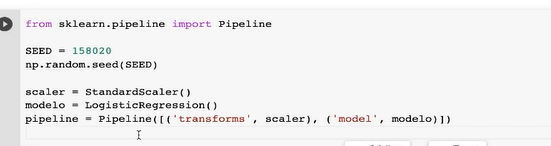

In [ ]:
from sklearn.pipeline import Pipeline

SEED = 158020
np.random.seed(SEED)

pipeline = Pipeline([
    ('escalado', StandardScaler()),
    ('modelo', LogisticRegression())
])
pipeline

Pipeline(steps=[('escalado', StandardScaler()),
                ('modelo', LogisticRegression())])

In [ ]:
from sklearn.pipeline import Pipeline

SEED = 158020
np.random.seed(SEED)

pipeline = Pipeline([
    ('escalado', StandardScaler()),
    ('modelo', LogisticRegression())
])

SEED = 234
np.random.seed(SEED)

cv = GroupKFold(n_splits=10)

modelo = LogisticRegression()

resultados = cross_validate(pipeline, x, y, cv=cv, groups=datos['modelo'])
imprime_resultadaos(resultados)

Nuestra media es 70.39
nuestro intervalo de confianza es [65.39, 75.38]
La exactitud media fue 70.39% (+/- 2.50%)
